In [1]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print("CLIENTS DATA")
print(clients.head())

print("\nCLIENTS INFO")
print(clients.info())

print("\nPROPERTIES DATA")
print(properties.head())

print("\nPROPERTIES INFO")
print(properties.info())

CLIENTS DATA
  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    05-11-1968      F     USA   
1     C0002  Individual    Trystan   Oconnor    11/26/1962      M     USA   
2     C0003  Individual       Kale       Gay    04-07-1959      M     USA   
3     C0004  Individual    Russell     Gross    11/25/1959      M     USA   
4     C0005     Company    Marleez        Co     2/28/1976      M     USA   

       region acquisition_purpose  satisfaction_score loan_applied  \
0  California                Home                   4          Yes   
1  California                Home                   1           No   
2  California                Home                   4          Yes   
3  California                Home                   5           No   
4  California          Investment                   5           No   

  referral_channel  
0          Website  
1          Website  
2           Agency  
3          Website 

In [2]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

print(clients.isnull().sum())
print()

print(properties.isnull().sum())
print()

print("Duplicates in Clients:",
      clients.duplicated().sum())

print("Duplicates in Properties:",
      properties.duplicated().sum())

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

Duplicates in Clients: 0
Duplicates in Properties: 0


In [3]:
print(properties['listing_status'].value_counts())

listing_status
Sold         7305
Available    2695
Name: count, dtype: int64


In [4]:
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    errors='coerce'
)

clients['age'] = (
    2026 -
    clients['date_of_birth'].dt.year
)

print(clients[['date_of_birth','age']].head())

  date_of_birth   age
0    1968-05-11  58.0
1           NaT   NaN
2    1959-04-07  67.0
3           NaT   NaN
4           NaT   NaN


In [5]:
properties['sale_price'] = (
    properties['sale_price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

print(properties['sale_price'].head())

0    300385.62
1    208930.81
2    218585.92
3    246172.68
4    212265.67
Name: sale_price, dtype: float64


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_11318/125740454.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


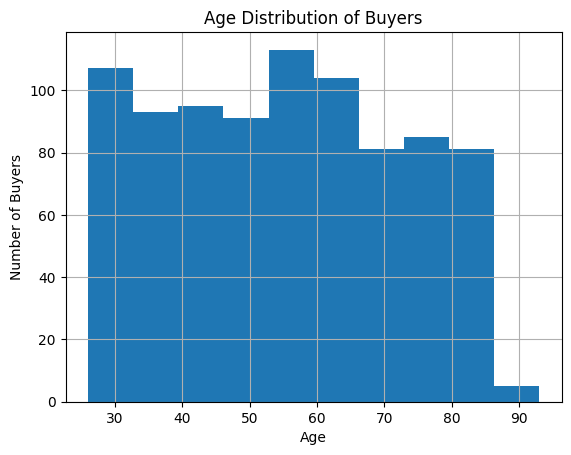

In [6]:
import matplotlib.pyplot as plt

clients['age'].hist(bins=10)

plt.title("Age Distribution of Buyers")
plt.xlabel("Age")
plt.ylabel("Number of Buyers")

plt.show()

In [7]:
print(clients['gender'].value_counts())
print(clients['client_type'].value_counts())
print(clients['acquisition_purpose'].value_counts())
print(clients['loan_applied'].value_counts())
print(clients['country'].value_counts())
print(clients['satisfaction_score'].describe())

gender
M    1012
F     988
Name: count, dtype: int64
client_type
Individual    1897
Company        103
Name: count, dtype: int64
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64
loan_applied
No     1264
Yes     736
Name: count, dtype: int64
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64
count    2000.000000
mean        3.029000
std         1.413562
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: satisfaction_score, dtype: float64


In [8]:
ml_data = clients.copy()

ml_data = ml_data[
[
'client_type',
'gender',
'country',
'region',
'acquisition_purpose',
'loan_applied',
'referral_channel',
'satisfaction_score',
'age'
]
]

print(ml_data.head())

  client_type gender country      region acquisition_purpose loan_applied  \
0  Individual      F     USA  California                Home          Yes   
1  Individual      M     USA  California                Home           No   
2  Individual      M     USA  California                Home          Yes   
3  Individual      M     USA  California                Home           No   
4     Company      M     USA  California          Investment           No   

  referral_channel  satisfaction_score   age  
0          Website                   4  58.0  
1          Website                   1   NaN  
2           Agency                   4  67.0  
3          Website                   5   NaN  
4          Website                   5   NaN  


In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
'client_type',
'gender',
'country',
'region',
'acquisition_purpose',
'loan_applied',
'referral_channel'
]

for col in categorical_columns:
    ml_data[col] = encoder.fit_transform(
        ml_data[col]
    )

print(ml_data.head())

   client_type  gender  country  region  acquisition_purpose  loan_applied  \
0            1       0        9       8                    0             1   
1            1       1        9       8                    0             0   
2            1       1        9       8                    0             1   
3            1       1        9       8                    0             0   
4            0       1        9       8                    1             0   

   referral_channel  satisfaction_score   age  
0                 2                   4  58.0  
1                 2                   1   NaN  
2                 0                   4  67.0  
3                 2                   5   NaN  
4                 2                   5   NaN  


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    ml_data
)

print(scaled_data.shape)

(2000, 9)


In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [12]:
print("Missing Ages:", ml_data['age'].isnull().sum())


Missing Ages: 1145


In [13]:
ml_data['age'] = ml_data['age'].fillna(
    ml_data['age'].median()
)

print("Missing Ages After Fix:",
      ml_data['age'].isnull().sum())

Missing Ages After Fix: 0


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    ml_data
)

print(scaled_data.shape)

(2000, 9)


In [15]:
import numpy as np

print(np.isnan(scaled_data).sum())

0


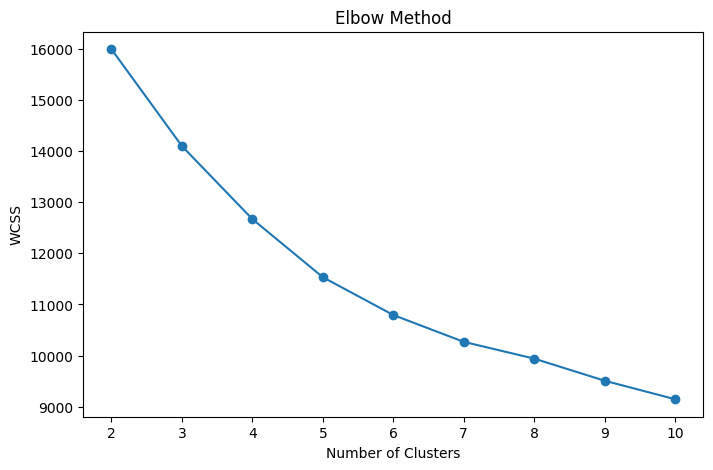

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         wcss,
         marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

ml_data['Cluster'] = clusters

print(ml_data['Cluster'].value_counts())

Cluster
3    729
1    508
2    426
0    234
4    103
Name: count, dtype: int64


In [18]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.16303929030770364


In [19]:
cluster_summary = ml_data.groupby('Cluster').mean()

print(cluster_summary)

         client_type    gender   country     region  acquisition_purpose  \
Cluster                                                                    
0                1.0  0.491453  2.115385  23.256410             0.303419   
1                1.0  0.513780  8.704724  20.931102             1.000000   
2                1.0  0.481221  8.673709  20.814554             0.000000   
3                1.0  0.504801  8.786008  21.131687             0.000000   
4                0.0  0.611650  8.029126  20.601942             0.349515   

         loan_applied  referral_channel  satisfaction_score        age  
Cluster                                                                 
0            0.316239          1.136752            3.059829  53.730769  
1            0.379921          1.173228            3.029528  55.637795  
2            1.000000          1.206573            2.943662  56.058685  
3            0.000000          1.240055            3.063100  56.513032  
4            0.417476        

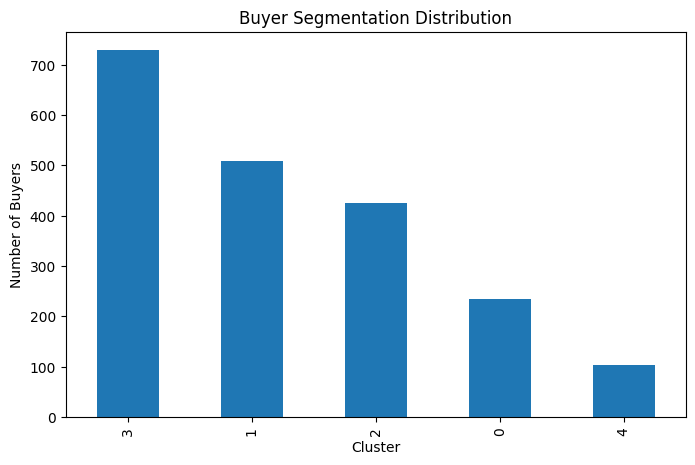

In [20]:
import matplotlib.pyplot as plt

cluster_counts = ml_data['Cluster'].value_counts()

plt.figure(figsize=(8,5))

cluster_counts.plot(
    kind='bar'
)

plt.title(
    'Buyer Segmentation Distribution'
)

plt.xlabel('Cluster')
plt.ylabel('Number of Buyers')

plt.show()

In [21]:
buyer_profiles = pd.DataFrame({
    'Cluster' : [0,1,2,3,4],
    'Buyer_Type' : [
        'International Investors',
        'Investment-Oriented Buyers',
        'Loan-Dependent Home Buyers',
        'Self-Financed Home Buyers',
        'Corporate Investors'
    ]
})

print(buyer_profiles)

   Cluster                  Buyer_Type
0        0     International Investors
1        1  Investment-Oriented Buyers
2        2  Loan-Dependent Home Buyers
3        3   Self-Financed Home Buyers
4        4         Corporate Investors


In [24]:
buyer_profiles.to_csv(
    'buyer_profiles.csv',
    index=False
)

In [25]:
ml_data.to_csv(
    "clustered_buyers.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [26]:
cluster_summary.to_csv(
    "cluster_summary.csv"
)

print("Summary Saved")

Summary Saved


In [27]:
buyer_profiles.to_csv(
    "buyer_profiles.csv",
    index=False
)

In [28]:
# Save clustered dataset
ml_data.to_csv(
    "clustered_buyers.csv",
    index=False
)

# Save cluster summary
cluster_summary.to_csv(
    "cluster_summary.csv"
)

# Save buyer profiles
buyer_profiles.to_csv(
    "buyer_profiles.csv",
    index=False
)

print("All files saved successfully!")

All files saved successfully!


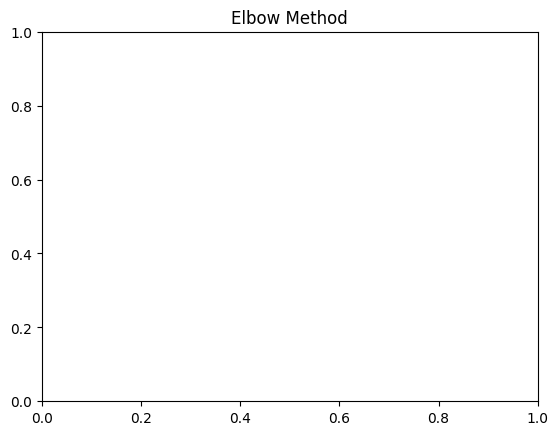

In [29]:
plt.title("Elbow Method")
plt.savefig("elbow_method.png", bbox_inches="tight")
plt.show()

In [30]:
from google.colab import files

files.download("elbow_method.png")
files.download("age_distribution.png")
files.download("cluster_distribution.png")
files.download("loan_analysis.png")
files.download("acquisition_purpose.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: age_distribution.png

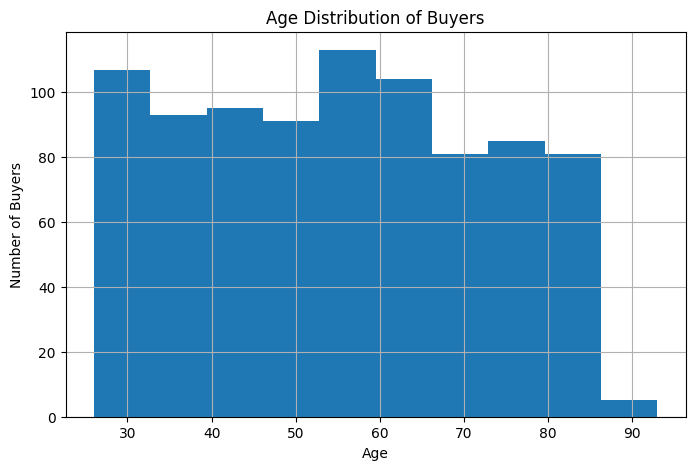

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

clients['age'].hist(bins=10)

plt.title("Age Distribution of Buyers")
plt.xlabel("Age")
plt.ylabel("Number of Buyers")

plt.savefig("age_distribution.png", bbox_inches="tight")

plt.show()

In [32]:
plt.savefig("elbow_method.png", bbox_inches="tight")
plt.savefig("cluster_distribution.png", bbox_inches="tight")
plt.savefig("loan_analysis.png", bbox_inches="tight")
plt.savefig("acquisition_purpose.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>